# imports

In [129]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
import seaborn as sns
from sklearn.model_selection import train_test_split
from datetime import datetime
from itertools import permutations
import numpy as np
from sklearn.metrics import f1_score, classification_report, r2_score, log_loss, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import cross_val_predict


## datasetes

### df

In [3]:
path = r'C:\Projects\Statbotics\RomiRotem\data\datasets\full_table2.csv'

df = pd.read_csv(path)

In [4]:
df

,actual_time,comp_level,event_key,key,match_number,post_result_time,set_number,time,videos,winning_alliance,...,teleopReef_topRow_nodeI,teleopReef_topRow_nodeJ,teleopReef_topRow_nodeK,teleopReef_topRow_nodeL,teleopReef_trough,wallAlgaeCount,team_number,scorePenaltyFree,possition,alliance
0,1.742056e+09,f,2025alhu,2025alhu_f1m1,1,1.742056e+09,1,1.742056e+09,"[{'key': 'NSWVoO4ZDEs', 'type': 'youtube'}]",blue,...,True,False,False,True,0.0,0.0,frc2783,124.0,1,red
1,1.742058e+09,f,2025alhu,2025alhu_f1m2,2,1.742058e+09,1,1.742057e+09,"[{'key': '1FpcfKgS3kw', 'type': 'youtube'}]",blue,...,True,True,True,False,0.0,0.0,frc2783,144.0,1,red
2,1.741960e+09,qm,2025alhu,2025alhu_qm1,1,1.741960e+09,1,1.741960e+09,"[{'key': 'mAbsfvQlhaw', 'type': 'youtube'}]",red,...,False,False,False,False,5.0,2.0,frc5045,129.0,1,red
3,1.741965e+09,qm,2025alhu,2025alhu_qm10,10,1.741965e+09,1,1.741965e+09,"[{'key': 'xrkAU-qZY-E', 'type': 'youtube'}]",red,...,True,True,True,True,1.0,0.0,frc538,112.0,1,red
4,1.741965e+09,qm,2025alhu,2025alhu_qm11,11,1.741965e+09,1,1.741965e+09,"[{'key': 'ae-lJ4geVPg', 'type': 'youtube'}]",blue,...,False,True,True,True,1.0,1.0,frc6107,61.0,1,red
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116377,1.752379e+09,sf,2025xxmel,2025xxmel_sf5m1,1,1.752379e+09,5,1.752378e+09,[],red,...,False,False,False,False,6.0,0.0,frc9995,64.0,3,blue
116378,1.752379e+09,sf,2025xxmel,2025xxmel_sf6m1,1,1.752379e+09,6,1.752379e+09,[],blue,...,False,False,False,False,1.0,0.0,frc9991,72.0,3,blue
116379,1.752380e+09,sf,2025xxmel,2025xxmel_sf7m1,1,1.752380e+09,7,1.752380e+09,[],red,...,False,False,False,False,0.0,0.0,frc9994,65.0,3,blue
116380,1.752380e+09,sf,2025xxmel,2025xxmel_sf8m1,1,1.752380e+09,8,1.752381e+09,[],red,...,False,True,True,True,14.0,0.0,frc9993,73.0,3,blue


### sdf

In [5]:
path1 = r'C:\Projects\Statbotics\RomiRotem\full_project\code\summery_df.csv'

sdf = pd.read_csv(path1)

In [6]:
sdf['endGame'] = sdf['endGame'].map({'Nothiing': 0, 'Parked': 1, 'ShallowCage': 2, 'DeepCage': 3})
sdf['endGame'] = sdf['endGame'].fillna(0)

In [7]:
sdf['team_number'] = sdf['team_number'].astype(str).str.extract(r'(\d+)').astype(int)
sdf.set_index(sdf.columns[0], inplace=True)
sdf = sdf.groupby(level=0).mean(numeric_only=True)
sdf.index.name = None

In [8]:
sdf = sdf.sort_index()

In [9]:
sdf.loc[2486]

score                         92.296202
autoLine                       0.873583
autoReef_tba_botRowCount       0.058390
autoReef_tba_midRowCount       0.015306
autoReef_tba_topRowCount       1.620465
autoReef_trough                0.234127
foulCount                      0.197846
netAlgaeCount                  1.898810
techFoulCount                  0.812925
teleopReef_tba_botRowCount     1.448980
teleopReef_tba_midRowCount     2.953515
teleopReef_tba_topRowCount     7.177721
teleopReef_trough              1.661848
wallAlgaeCount                 0.747449
endGame                        2.000000
possition                      2.000000
quality                       -0.405392
Name: 2486, dtype: float64

# prepares

In [10]:
df

,actual_time,comp_level,event_key,key,match_number,post_result_time,set_number,time,videos,winning_alliance,...,teleopReef_topRow_nodeI,teleopReef_topRow_nodeJ,teleopReef_topRow_nodeK,teleopReef_topRow_nodeL,teleopReef_trough,wallAlgaeCount,team_number,scorePenaltyFree,possition,alliance
0,1.742056e+09,f,2025alhu,2025alhu_f1m1,1,1.742056e+09,1,1.742056e+09,"[{'key': 'NSWVoO4ZDEs', 'type': 'youtube'}]",blue,...,True,False,False,True,0.0,0.0,frc2783,124.0,1,red
1,1.742058e+09,f,2025alhu,2025alhu_f1m2,2,1.742058e+09,1,1.742057e+09,"[{'key': '1FpcfKgS3kw', 'type': 'youtube'}]",blue,...,True,True,True,False,0.0,0.0,frc2783,144.0,1,red
2,1.741960e+09,qm,2025alhu,2025alhu_qm1,1,1.741960e+09,1,1.741960e+09,"[{'key': 'mAbsfvQlhaw', 'type': 'youtube'}]",red,...,False,False,False,False,5.0,2.0,frc5045,129.0,1,red
3,1.741965e+09,qm,2025alhu,2025alhu_qm10,10,1.741965e+09,1,1.741965e+09,"[{'key': 'xrkAU-qZY-E', 'type': 'youtube'}]",red,...,True,True,True,True,1.0,0.0,frc538,112.0,1,red
4,1.741965e+09,qm,2025alhu,2025alhu_qm11,11,1.741965e+09,1,1.741965e+09,"[{'key': 'ae-lJ4geVPg', 'type': 'youtube'}]",blue,...,False,True,True,True,1.0,1.0,frc6107,61.0,1,red
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116377,1.752379e+09,sf,2025xxmel,2025xxmel_sf5m1,1,1.752379e+09,5,1.752378e+09,[],red,...,False,False,False,False,6.0,0.0,frc9995,64.0,3,blue
116378,1.752379e+09,sf,2025xxmel,2025xxmel_sf6m1,1,1.752379e+09,6,1.752379e+09,[],blue,...,False,False,False,False,1.0,0.0,frc9991,72.0,3,blue
116379,1.752380e+09,sf,2025xxmel,2025xxmel_sf7m1,1,1.752380e+09,7,1.752380e+09,[],red,...,False,False,False,False,0.0,0.0,frc9994,65.0,3,blue
116380,1.752380e+09,sf,2025xxmel,2025xxmel_sf8m1,1,1.752380e+09,8,1.752381e+09,[],red,...,False,True,True,True,14.0,0.0,frc9993,73.0,3,blue


In [11]:
#dropping teams with less than 10 games
teams_to_drop = ['frc9990', 'frc9991', 'frc9992', 'frc9993', 'frc9994', 'frc9995', 'frc9996', 'frc9997', 'frc9998', 'frc9999']

for team in df['team_number'].unique():
    if df.loc[df['team_number'] == team].shape[0] < 10:
        teams_to_drop.append(team)

df = df[~df['team_number'].isin(teams_to_drop)]

In [12]:
#adding column "win"
df['win'] = df['winning_alliance'] == df['alliance']

C:\Users\user\AppData\Local\Temp\ipykernel_16096\1783187918.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['win'] = df['winning_alliance'] == df['alliance']


In [13]:
#mapping data
df["comp_level"] = df["comp_level"].map({'qm': 1, 'sf': 2, 'f': 3})
df['winning_alliance'] = df['winning_alliance'].map({'blue': 1, 'red': 2})
df['winning_alliance'] = df['winning_alliance'].fillna(0)
df['alliance'] = df['alliance'].map({'blue': 1, 'red': 2})
df['actual_time'] = pd.to_datetime(df['actual_time'], unit='s').dt.hour
df['team_number'] = df['team_number'].astype(str).str.extract(r'(\d+)').astype(int)

# pre-match data

In [14]:
df.head(1)

,actual_time,comp_level,event_key,key,match_number,post_result_time,set_number,time,videos,winning_alliance,...,teleopReef_topRow_nodeJ,teleopReef_topRow_nodeK,teleopReef_topRow_nodeL,teleopReef_trough,wallAlgaeCount,team_number,scorePenaltyFree,possition,alliance,win
0,16,3,2025alhu,2025alhu_f1m1,1,1.742056e+09,1,1.742056e+09,"[{'key': 'NSWVoO4ZDEs', 'type': 'youtube'}]",1.0,...,False,False,True,0.0,0.0,2783,124.0,1,2,False


In [15]:
df.loc[df['team_number'] == 991]

,actual_time,comp_level,event_key,key,match_number,post_result_time,set_number,time,videos,winning_alliance,...,teleopReef_topRow_nodeJ,teleopReef_topRow_nodeK,teleopReef_topRow_nodeL,teleopReef_trough,wallAlgaeCount,team_number,scorePenaltyFree,possition,alliance,win
452,0,1,2025azfg,2025azfg_qm52,52,1.741999e+09,1,1.741996e+09,"[{'key': 'HCsnR-Mmo1I', 'type': 'youtube'}]",1.0,...,False,False,False,0.0,2.0,991,49.0,1,2,False
483,19,1,2025azfg,2025azfg_qm80,80,1.742066e+09,1,1.742065e+09,"[{'key': 'szWijLLdCsA', 'type': 'youtube'}]",1.0,...,False,False,False,1.0,2.0,991,31.0,1,2,False
622,16,1,2025azrl2,2025azrl2_qm1,1,1.751129e+09,1,1.751129e+09,"[{'key': 'UzuB1Se-gDc', 'type': 'youtube'}]",1.0,...,True,False,False,0.0,1.0,991,51.0,1,2,False
633,17,1,2025azrl2,2025azrl2_qm3,3,1.751132e+09,1,1.751131e+09,"[{'key': '51_tn6sDH2g', 'type': 'youtube'}]",1.0,...,False,False,False,3.0,0.0,991,11.0,1,2,False
637,18,1,2025azrl2,2025azrl2_qm7,7,1.751135e+09,1,1.751134e+09,"[{'key': 'cKkopwnRChk', 'type': 'youtube'}]",2.0,...,False,False,False,12.0,2.0,991,109.0,1,2,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97722,22,1,2025azrl5,2025azrl5_qm32,32,1.758408e+09,1,1.758407e+09,"[{'key': 'kciwF2fTwFY', 'type': 'youtube'}]",1.0,...,False,False,False,1.0,1.0,991,36.0,3,1,True
98789,22,1,2025caph,2025caph_qm36,36,1.740870e+09,1,1.740869e+09,"[{'key': '-77W7mN7dbg', 'type': 'youtube'}]",2.0,...,False,False,False,0.0,1.0,991,53.0,3,1,False
98823,18,1,2025caph,2025caph_qm67,67,1.740940e+09,1,1.740939e+09,"[{'key': 'McahZ6KQvu0', 'type': 'youtube'}]",2.0,...,False,False,False,8.0,6.0,991,90.0,3,1,False
110040,21,1,2025nvlv,2025nvlv_qm33,33,1.743198e+09,1,1.743196e+09,"[{'key': 'WrZRQtU9QGw', 'type': 'youtube'}]",1.0,...,False,False,False,8.0,9.0,991,85.0,3,1,True


In [16]:
pdf = df[['key', 'actual_time', 'comp_level', 'team_number', 'possition', 'alliance', 'win']]
#prematch data frame

In [17]:
pdf

,key,actual_time,comp_level,team_number,possition,alliance,win
0,2025alhu_f1m1,16,3,2783,1,2,False
1,2025alhu_f1m2,16,3,2783,1,2,False
2,2025alhu_qm1,13,1,5045,1,2,True
3,2025alhu_qm10,15,1,538,1,2,True
4,2025alhu_qm11,15,1,6107,1,2,False
...,...,...,...,...,...,...,...
116366,2025xxmel_qm7,0,1,7128,3,1,False
116368,2025xxmel_qm9,1,1,6996,3,1,True
116369,2025xxmel_sf10m1,4,2,5648,3,1,False
116370,2025xxmel_sf11m1,4,2,10002,3,1,False


In [18]:
pdf.loc[pdf['key'] == '2025alhu_qm10']

,key,actual_time,comp_level,team_number,possition,alliance,win
3,2025alhu_qm10,15,1,538,1,2,True
19400,2025alhu_qm10,15,1,2338,2,2,True
38797,2025alhu_qm10,15,1,2973,3,2,True
58194,2025alhu_qm10,15,1,3138,1,1,False
77591,2025alhu_qm10,15,1,3843,2,1,False
96988,2025alhu_qm10,15,1,4020,3,1,False


In [19]:
sdf

,score,autoLine,autoReef_tba_botRowCount,autoReef_tba_midRowCount,autoReef_tba_topRowCount,autoReef_trough,foulCount,netAlgaeCount,techFoulCount,teleopReef_tba_botRowCount,teleopReef_tba_midRowCount,teleopReef_tba_topRowCount,teleopReef_trough,wallAlgaeCount,endGame,possition,quality
1,86.321429,0.928571,0.000000,0.000000,1.214286,0.285714,0.142857,0.607143,0.178571,2.357143,2.750000,6.178571,2.571429,0.714286,1.0,1.0,-23.344473
4,116.204545,0.977273,0.068182,0.045455,1.454545,0.340909,0.272727,2.840909,0.704545,3.636364,5.681818,6.431818,1.545455,1.522727,1.0,3.0,3.728177
8,119.888889,1.000000,0.037037,0.000000,2.777778,0.185185,0.185185,1.407407,0.629630,2.148148,4.592593,10.259259,1.111111,0.703704,3.0,3.0,12.070774
11,149.234375,0.984375,0.046875,0.000000,2.828125,0.375000,0.171875,4.109375,0.328125,3.671875,5.875000,9.921875,2.046875,0.953125,3.0,2.0,31.859901
16,153.065217,0.934783,0.000000,0.000000,3.304348,0.152174,0.282609,4.869565,0.695652,3.717391,6.869565,9.826087,2.456522,0.782609,3.0,1.0,24.112880
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10705,75.458333,1.000000,0.083333,0.000000,0.708333,0.958333,0.166667,1.000000,0.625000,1.125000,1.416667,5.333333,4.500000,0.458333,1.0,1.0,-18.075492
10714,105.111111,0.888889,0.000000,0.000000,1.444444,1.000000,0.888889,1.555556,0.222222,1.777778,2.000000,9.111111,4.888889,0.888889,0.0,1.0,-3.279269
10905,51.000000,0.583333,0.166667,0.000000,0.250000,0.416667,0.083333,0.416667,0.750000,0.750000,0.250000,4.666667,0.583333,0.500000,1.0,1.0,-29.052520
10988,57.833333,0.750000,0.000000,0.166667,0.416667,0.166667,0.083333,0.666667,0.833333,0.750000,2.000000,4.083333,0.750000,0.750000,1.0,1.0,-20.519609


In [20]:
def alliance_pairs(data, sdf):
    if data is None or len(data) < 2:
        return pd.DataFrame()

    new_rows = []
    sdf_cols = sdf.columns.tolist()

    for (i1, row1), (i2, row2) in permutations(data.iterrows(), 2):
        
        new_row_data = {
            'key': row1['key'],
            'actual_time': row1['actual_time'],
            'comp_level': row1['comp_level'],
            'team_number1': row1['team_number'],
            'team_number2': row2['team_number'],
            'possition1': row1['possition'],
            'possition2': row2['possition'],
            'alliance': row1['alliance'],
            'win': row1['win']
        }
        
        t1 = row1['team_number']
        if t1 in sdf.index:
            stats1 = sdf.loc[t1]
            for col in sdf_cols:
                new_row_data[f'S_{col}_team1'] = stats1[col]

        t2 = row2['team_number']
        if t2 in sdf.index:
            stats2 = sdf.loc[t2]
            for col in sdf_cols:
                new_row_data[f'S_{col}_team2'] = stats2[col]

        new_rows.append(new_row_data)
        
    return pd.DataFrame(new_rows)


In [21]:
pdf

,key,actual_time,comp_level,team_number,possition,alliance,win
0,2025alhu_f1m1,16,3,2783,1,2,False
1,2025alhu_f1m2,16,3,2783,1,2,False
2,2025alhu_qm1,13,1,5045,1,2,True
3,2025alhu_qm10,15,1,538,1,2,True
4,2025alhu_qm11,15,1,6107,1,2,False
...,...,...,...,...,...,...,...
116366,2025xxmel_qm7,0,1,7128,3,1,False
116368,2025xxmel_qm9,1,1,6996,3,1,True
116369,2025xxmel_sf10m1,4,2,5648,3,1,False
116370,2025xxmel_sf11m1,4,2,10002,3,1,False


In [22]:
pdf.loc[pdf['team_number'] == 2486]

,key,actual_time,comp_level,team_number,possition,alliance,win
408,2025azfg_qm12,17,1,2486,1,2,False
425,2025azfg_qm28,21,1,2486,1,2,False
449,2025azfg_qm5,16,1,2486,1,2,False
451,2025azfg_qm51,0,1,2486,1,2,True
485,2025azfg_sf10m1,21,2,2486,1,2,False
...,...,...,...,...,...,...,...
97708,2025azrl5_qm2,17,1,2486,3,1,False
97717,2025azrl5_qm28,22,1,2486,3,1,False
98689,2025caoc_qm30,22,1,2486,3,1,False
98721,2025caoc_qm6,17,1,2486,3,1,False


In [23]:
sdf.shape

(3710, 17)

In [24]:
sdf.loc[2486]

score                         92.296202
autoLine                       0.873583
autoReef_tba_botRowCount       0.058390
autoReef_tba_midRowCount       0.015306
autoReef_tba_topRowCount       1.620465
autoReef_trough                0.234127
foulCount                      0.197846
netAlgaeCount                  1.898810
techFoulCount                  0.812925
teleopReef_tba_botRowCount     1.448980
teleopReef_tba_midRowCount     2.953515
teleopReef_tba_topRowCount     7.177721
teleopReef_trough              1.661848
wallAlgaeCount                 0.747449
endGame                        2.000000
possition                      2.000000
quality                       -0.405392
Name: 2486, dtype: float64

In [25]:
sdf[sdf.index.duplicated(keep=False)]

,score,autoLine,autoReef_tba_botRowCount,autoReef_tba_midRowCount,autoReef_tba_topRowCount,autoReef_trough,foulCount,netAlgaeCount,techFoulCount,teleopReef_tba_botRowCount,teleopReef_tba_midRowCount,teleopReef_tba_topRowCount,teleopReef_trough,wallAlgaeCount,endGame,possition,quality


In [26]:
data= pdf.loc[(pdf['key'] == '2025azfg_qm12')] #(pdf['team_number'] == 2486)]
new_rows = []
sdf_cols = sdf.columns.tolist()

for (i1, row1), (i2, row2) in permutations(data.iterrows(), 2):
    
    new_row_data = {
        'key': row1['key'],
        'actual_time': row1['actual_time'],
        'comp_level': row1['comp_level'],
        'team_number1': row1['team_number'],
        'team_number2': row2['team_number'],
        'possition1': row1['possition'],
        'possition2': row2['possition'],
        'alliance': row1['alliance'],
        'win': row1['win']
    }
    
    t1 = row1['team_number']
    print(f" team_number: {t1}")
    if t1 in sdf.index:
        stats1 = sdf.loc[t1]
        for col in sdf_cols:
            new_row_data[f'S_{col}_team1'] = stats1[col]
            print(f"col: {col}:\n stats: {stats1[col]}")

    t2 = row2['team_number']
    if t2 in sdf.index:
        stats2 = sdf.loc[t2]
        for col in sdf_cols:
            new_row_data[f'S_{col}_team2'] = stats2[col]

    new_rows.append(new_row_data)
# pd.DataFrame(new_rows)['S_score_team1']#.at[1,'S_score_team1']

 team_number: 2486
col: score:
 stats: 92.29620181405895
col: autoLine:
 stats: 0.8735827664399093
col: autoReef_tba_botRowCount:
 stats: 0.0583900226757369
col: autoReef_tba_midRowCount:
 stats: 0.01530612244897955
col: autoReef_tba_topRowCount:
 stats: 1.6204648526077097
col: autoReef_trough:
 stats: 0.2341269841269841
col: foulCount:
 stats: 0.1978458049886621
col: netAlgaeCount:
 stats: 1.8988095238095237
col: techFoulCount:
 stats: 0.8129251700680272
col: teleopReef_tba_botRowCount:
 stats: 1.4489795918367345
col: teleopReef_tba_midRowCount:
 stats: 2.953514739229025
col: teleopReef_tba_topRowCount:
 stats: 7.177721088435375
col: teleopReef_trough:
 stats: 1.6618480725623583
col: wallAlgaeCount:
 stats: 0.7474489795918368
col: endGame:
 stats: 2.0
col: possition:
 stats: 2.0
col: quality:
 stats: -0.4053917842577164
 team_number: 2486
col: score:
 stats: 92.29620181405895
col: autoLine:
 stats: 0.8735827664399093
col: autoReef_tba_botRowCount:
 stats: 0.0583900226757369
col: autoR

In [27]:
alliance_pairs(pdf.loc[(pdf['key'] == '2025alhu_qm10') & (pdf['alliance'] == 2)], sdf)

,key,actual_time,comp_level,team_number1,team_number2,possition1,possition2,alliance,win,S_score_team1,...,S_netAlgaeCount_team2,S_techFoulCount_team2,S_teleopReef_tba_botRowCount_team2,S_teleopReef_tba_midRowCount_team2,S_teleopReef_tba_topRowCount_team2,S_teleopReef_trough_team2,S_wallAlgaeCount_team2,S_endGame_team2,S_possition_team2,S_quality_team2
0,2025alhu_qm10,15,1,538,2338,1,2,2,True,78.238095,...,3.596154,0.288462,6.480769,8.307692,10.961538,3.230769,1.038462,3.0,2.0,44.617464
1,2025alhu_qm10,15,1,538,2973,1,3,2,True,78.238095,...,1.300000,0.850000,1.050000,1.300000,6.100000,1.000000,0.650000,1.0,1.0,-25.656720
2,2025alhu_qm10,15,1,2338,538,2,1,2,True,177.288462,...,1.523810,0.333333,1.476190,2.238095,5.333333,1.761905,1.190476,1.0,3.0,-23.862662
3,2025alhu_qm10,15,1,2338,2973,2,3,2,True,177.288462,...,1.300000,0.850000,1.050000,1.300000,6.100000,1.000000,0.650000,1.0,1.0,-25.656720
4,2025alhu_qm10,15,1,2973,538,3,1,2,True,68.800000,...,1.523810,0.333333,1.476190,2.238095,5.333333,1.761905,1.190476,1.0,3.0,-23.862662
5,2025alhu_qm10,15,1,2973,2338,3,2,2,True,68.800000,...,3.596154,0.288462,6.480769,8.307692,10.961538,3.230769,1.038462,3.0,2.0,44.617464


In [28]:
alliance_pairs(pdf.loc[pdf['team_number'] == 2486], sdf)['S_score_team1']

0        92.296202
1        92.296202
2        92.296202
3        92.296202
4        92.296202
           ...    
17817    92.296202
17818    92.296202
17819    92.296202
17820    92.296202
17821    92.296202
Name: S_score_team1, Length: 17822, dtype: float64

In [29]:
pdf

,key,actual_time,comp_level,team_number,possition,alliance,win
0,2025alhu_f1m1,16,3,2783,1,2,False
1,2025alhu_f1m2,16,3,2783,1,2,False
2,2025alhu_qm1,13,1,5045,1,2,True
3,2025alhu_qm10,15,1,538,1,2,True
4,2025alhu_qm11,15,1,6107,1,2,False
...,...,...,...,...,...,...,...
116366,2025xxmel_qm7,0,1,7128,3,1,False
116368,2025xxmel_qm9,1,1,6996,3,1,True
116369,2025xxmel_sf10m1,4,2,5648,3,1,False
116370,2025xxmel_sf11m1,4,2,10002,3,1,False


In [30]:

frames = []
for k in pdf['key'].unique():
    for i in range(1, 3):
        subset = pdf[(pdf['key'] == k) & (pdf['alliance'] == i)]
        
        processed_data = alliance_pairs(subset, sdf)
        
        if not processed_data.empty:
            frames.append(processed_data)

if frames:
    dpdf = pd.concat(frames, ignore_index=True)
else:
    dpdf = pd.DataFrame()
#dpdf = duplicated prematch data frame

In [31]:
dpdf

,key,actual_time,comp_level,team_number1,team_number2,possition1,possition2,alliance,win,S_score_team1,...,S_netAlgaeCount_team2,S_techFoulCount_team2,S_teleopReef_tba_botRowCount_team2,S_teleopReef_tba_midRowCount_team2,S_teleopReef_tba_topRowCount_team2,S_teleopReef_trough_team2,S_wallAlgaeCount_team2,S_endGame_team2,S_possition_team2,S_quality_team2
0,2025alhu_f1m1,16,3,2338,4020,1,2,1,True,177.288462,...,2.133333,0.200000,6.155556,8.422222,10.177778,2.466667,2.511111,3.0,3.0,41.884800
1,2025alhu_f1m1,16,3,2338,10011,1,3,1,True,177.288462,...,2.229167,0.729167,3.333333,5.229167,6.958333,0.770833,1.395833,1.0,3.0,-7.911266
2,2025alhu_f1m1,16,3,4020,2338,2,1,1,True,166.888889,...,3.596154,0.288462,6.480769,8.307692,10.961538,3.230769,1.038462,3.0,2.0,44.617464
3,2025alhu_f1m1,16,3,4020,10011,2,3,1,True,166.888889,...,2.229167,0.729167,3.333333,5.229167,6.958333,0.770833,1.395833,1.0,3.0,-7.911266
4,2025alhu_f1m1,16,3,10011,2338,3,1,1,True,114.166667,...,3.596154,0.288462,6.480769,8.307692,10.961538,3.230769,1.038462,3.0,2.0,44.617464
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
221637,2025tuis_qm45,15,1,9523,6014,3,2,1,True,79.241379,...,1.950000,0.350000,3.350000,4.550000,7.150000,2.050000,0.850000,1.0,2.0,-0.261680
221638,2025tuis2_qm35,12,1,10528,9610,2,3,1,False,54.272727,...,0.777778,1.388889,0.666667,0.555556,3.055556,2.555556,0.944444,0.0,1.0,-28.273517
221639,2025tuis2_qm35,12,1,9610,10528,3,2,1,False,48.333333,...,0.181818,0.909091,1.818182,2.000000,1.000000,4.909091,0.181818,1.0,3.0,-10.539770
221640,2025tuis3_qm44,14,1,10598,9483,2,3,1,True,97.114286,...,2.162791,0.395349,6.395349,8.581395,9.790698,4.139535,0.511628,1.0,2.0,50.141544


# logistic reggresion

In [32]:
X = dpdf.drop(['win', 'key', 'alliance'], axis = 1)
y = dpdf['win']

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.4, random_state = 42)

In [34]:
X_test1, X_test2, y_test1, y_test2 = train_test_split(X_test, y_test, test_size = 0.5, random_state = 42)

In [35]:
y_train

39018     False
185572     True
90004      True
84902      True
109431     True
          ...  
119879    False
103694     True
131932    False
146867    False
121958    False
Name: win, Length: 132985, dtype: bool

In [36]:
X_train = X_train.astype(float)

In [37]:
X_train.iloc[63]

actual_time                             20.000000
comp_level                               1.000000
team_number1                          2486.000000
team_number2                          9091.000000
possition1                               3.000000
possition2                               2.000000
S_score_team1                           92.296202
S_autoLine_team1                         0.873583
S_autoReef_tba_botRowCount_team1         0.058390
S_autoReef_tba_midRowCount_team1         0.015306
S_autoReef_tba_topRowCount_team1         1.620465
S_autoReef_trough_team1                  0.234127
S_foulCount_team1                        0.197846
S_netAlgaeCount_team1                    1.898810
S_techFoulCount_team1                    0.812925
S_teleopReef_tba_botRowCount_team1       1.448980
S_teleopReef_tba_midRowCount_team1       2.953515
S_teleopReef_tba_topRowCount_team1       7.177721
S_teleopReef_trough_team1                1.661848
S_wallAlgaeCount_team1                   0.747449


In [38]:

clf = LogisticRegression(random_state=0).fit(X_train, y_train)

c:\Projects\Statbotics\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## threshhold 0.5

In [39]:
y_pred = clf.predict(X_test1)
f1 = f1_score(y_test1, y_pred)
print(f"F1-Score: {f1:.4f}")

F1-Score: 0.6179


In [40]:
print("0.5: \n",classification_report(y_test1, y_pred))

0.5: 
               precision    recall  f1-score   support

       False       0.62      0.66      0.64     21952
        True       0.64      0.60      0.62     22376

    accuracy                           0.63     44328
   macro avg       0.63      0.63      0.63     44328
weighted avg       0.63      0.63      0.63     44328



## threshhold k

In [41]:
ks = {}

In [42]:
for k in range(10):
    y_probs = clf.predict_proba(X_test2)[:, 1]
    custom_threshold = k/10
    y_pred_custom = (y_probs >= custom_threshold).astype(int)
    f1 = f1_score(y_test2, y_pred_custom)
    ks[k/10] = f1
    print(f"F1-Score: {f1:.4f}")

F1-Score: 0.6671
F1-Score: 0.6671
F1-Score: 0.6678
F1-Score: 0.6789
F1-Score: 0.6793
F1-Score: 0.6157
F1-Score: 0.4689
F1-Score: 0.2725
F1-Score: 0.0925
F1-Score: 0.0088


In [43]:
ks

{0.0: 0.6671377241908084,
 0.1: 0.6671377241908084,
 0.2: 0.6678211112784219,
 0.3: 0.6788544926062994,
 0.4: 0.6792740525865596,
 0.5: 0.6156997858273582,
 0.6: 0.4689397754539799,
 0.7: 0.2724641928275761,
 0.8: 0.09245762711864407,
 0.9: 0.008788449466415568}

<Axes: >

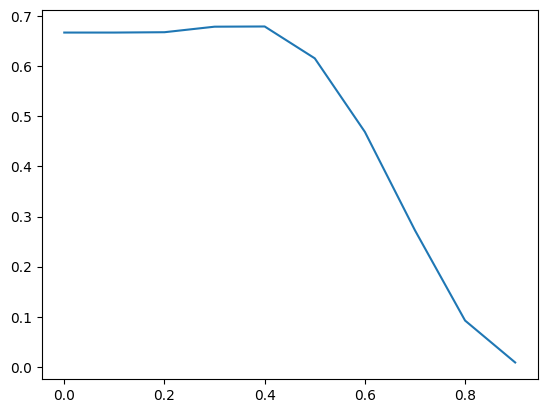

In [44]:
sns.lineplot(x=list(ks.keys()), y=list(ks.values()))

In [45]:
y_probs = clf.predict_proba(X_test2)[:, 1]
custom_threshold = 0.4
y_pred_custom = (y_probs >= custom_threshold).astype(int)
f1 = f1_score(y_test2, y_pred_custom)
print(f"F1-Score: {f1:.4f}")

F1-Score: 0.6793


In [46]:
print("0.4: \n",classification_report(y_test2, y_pred_custom))

0.4: 
               precision    recall  f1-score   support

       False       0.69      0.40      0.51     22141
        True       0.58      0.82      0.68     22188

    accuracy                           0.61     44329
   macro avg       0.64      0.61      0.59     44329
weighted avg       0.64      0.61      0.59     44329



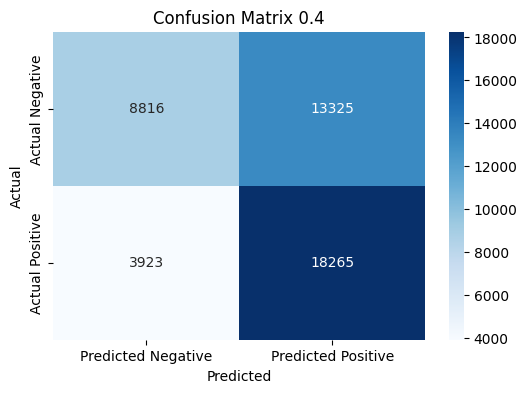

In [47]:
cm = confusion_matrix(y_test2, y_pred_custom)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix 0.4')
plt.show()

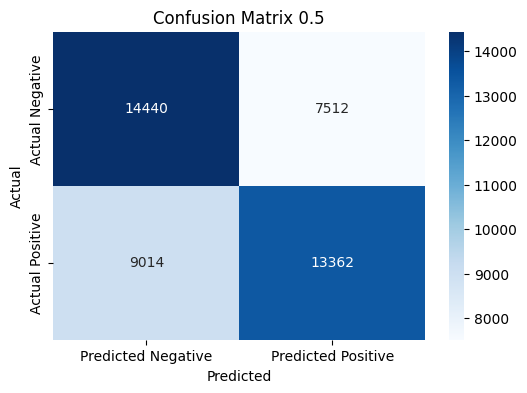

In [48]:
cm = confusion_matrix(y_test1, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix 0.5')
plt.show()

In [49]:
print("0.5: ",r2_score(y_test1, y_pred))
print("0.4: ",r2_score(y_test2, y_pred_custom))

0.5:  -0.49138351456318774
0.4:  -0.5563644015577855


In [50]:
print("0.5: ",log_loss(y_test1, y_pred))
print("0.4: ",log_loss(y_test2, y_pred_custom))

0.5:  13.437498102972162
0.4:  14.024248994010524


In [127]:
y_probs_full = clf.predict_proba(X_test)[:, 1]
custom_threshold = 0.5
y_pred_full = (y_probs >= custom_threshold).astype(int)

In [79]:
tdf = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred_full.astype(bool),
    'Probability': y_probs_full,
    "team1": X_test["team_number1"],
    "team2": X_test["team_number2"]
})
# test df

In [80]:
tdf["Wrong"] = tdf["Actual"] != tdf["Predicted"]

In [81]:
tdf

,Actual,Predicted,Probability,team1,team2,Wrong
114633,False,True,0.591855,1732,8122,True
152596,True,True,0.546182,3624,4122,False
158710,False,False,0.391005,3247,2333,False
189490,True,False,0.434247,9492,5613,True
111866,True,True,0.622949,862,5084,False
...,...,...,...,...,...,...
170864,False,False,0.209673,2733,2898,False
151323,False,False,0.409072,7165,5881,False
173719,False,False,0.356436,5113,1647,False
158991,True,False,0.423373,2080,10219,True


In [82]:
w = 0.8
wtdf = tdf.loc[(tdf["Wrong"]) & ((tdf["Probability"] > w) | (tdf["Probability"] < (1-w)))]
# wierds test df

In [83]:
wtdf

,Actual,Predicted,Probability,team1,team2,Wrong
46646,False,True,0.804488,973,2075,True
121802,False,True,0.866979,341,5895,True
32090,False,True,0.850215,6329,4481,True
9904,False,True,0.854325,3128,5468,True
26792,False,True,0.813610,16,180,True
...,...,...,...,...,...,...
67791,False,True,0.805286,88,125,True
55593,False,True,0.870878,2075,868,True
55744,False,True,0.875395,694,2075,True
72011,True,False,0.194756,9056,4473,True


In [84]:
dpdf.loc[(dpdf["team_number1"] == 2056) & (dpdf["team_number2"] == 1690)]

,key,actual_time,comp_level,team_number1,team_number2,possition1,possition2,alliance,win,S_score_team1,...,S_netAlgaeCount_team2,S_techFoulCount_team2,S_teleopReef_tba_botRowCount_team2,S_teleopReef_tba_midRowCount_team2,S_teleopReef_tba_topRowCount_team2,S_teleopReef_trough_team2,S_wallAlgaeCount_team2,S_endGame_team2,S_possition_team2,S_quality_team2
55477,2025iri_f1m1,20,3,2056,1690,3,2,2,True,229.741573,...,5.270588,0.458824,8.823529,9.858824,11.082353,9.905882,1.094118,3.0,2.0,75.592104
55489,2025iri_f1m2,21,3,2056,1690,3,2,2,False,229.741573,...,5.270588,0.458824,8.823529,9.858824,11.082353,9.905882,1.094118,3.0,2.0,75.592104
56581,2025iri_sf11m1,19,2,2056,1690,3,2,2,True,229.741573,...,5.270588,0.458824,8.823529,9.858824,11.082353,9.905882,1.094118,3.0,2.0,75.592104
56617,2025iri_sf1m1,18,2,2056,1690,3,2,2,True,229.741573,...,5.270588,0.458824,8.823529,9.858824,11.082353,9.905882,1.094118,3.0,2.0,75.592104
56689,2025iri_sf7m1,19,2,2056,1690,3,2,2,True,229.741573,...,5.270588,0.458824,8.823529,9.858824,11.082353,9.905882,1.094118,3.0,2.0,75.592104


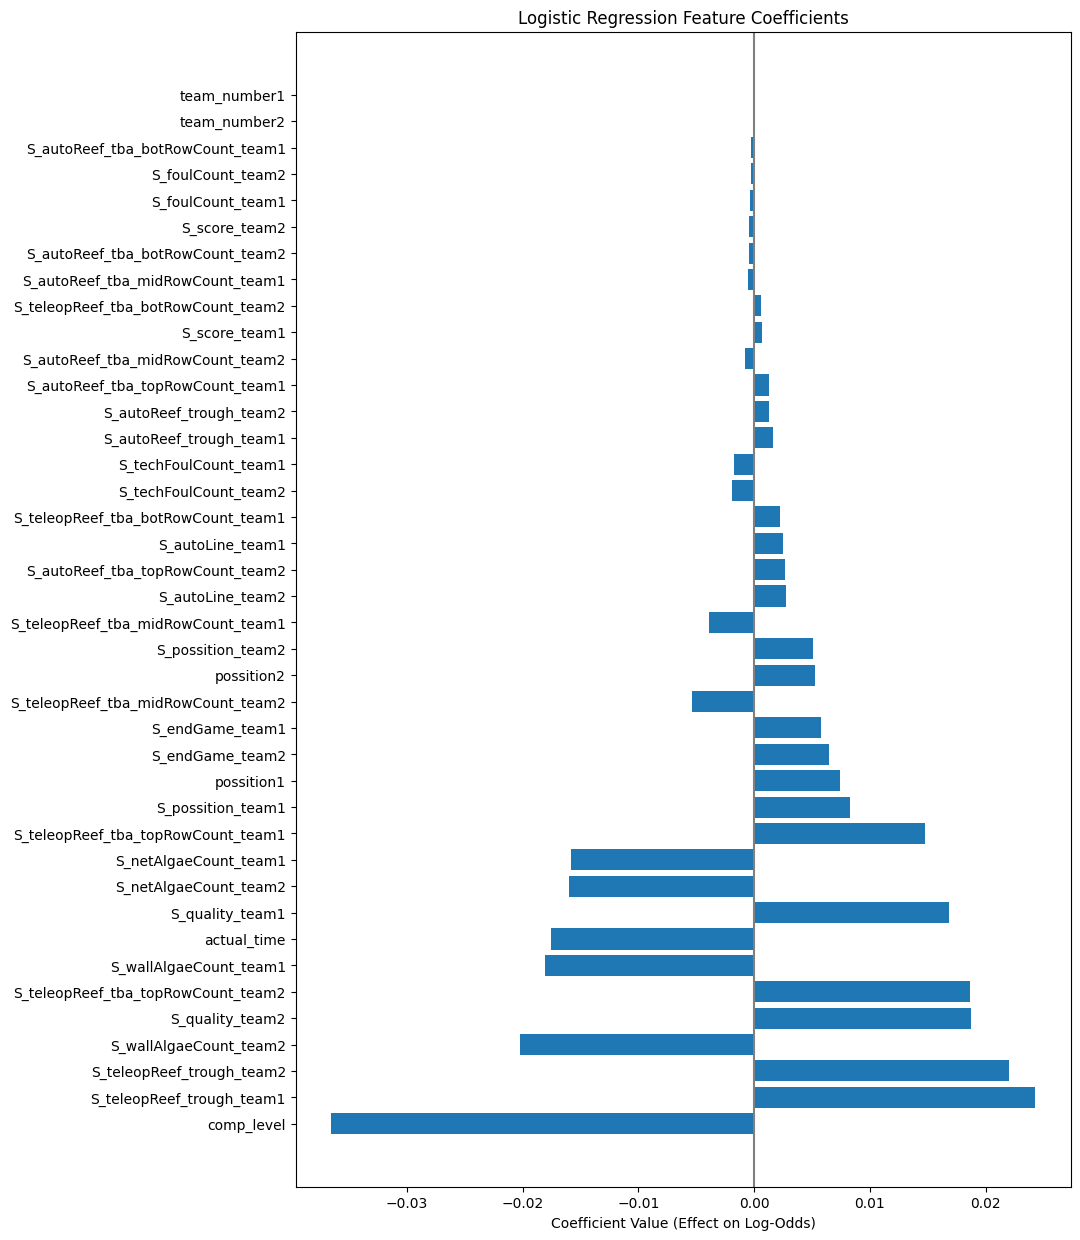

In [91]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
coefficients = clf.coef_[0]

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': coefficients,
    'Absolute_Importance': abs(coefficients)
})
feature_importance = feature_importance.sort_values(by='Absolute_Importance', ascending=False)
# print(feature_importance)
plt.figure(figsize=(10, 15))
plt.barh(feature_importance['Feature'], feature_importance['Coefficient'])
plt.title("Logistic Regression Feature Coefficients")
plt.xlabel("Coefficient Value (Effect on Log-Odds)")
plt.axvline(x=0, color='.5')
plt.show()

## improvments

### normalize

In [115]:
scaler = MinMaxScaler()
scaled_array = scaler.fit_transform(X.drop(['comp_level', 'team_number1', 'team_number2', 'possition1', 'possition2'], axis = 1))
nX = pd.DataFrame(scaled_array, columns=X.drop(['comp_level', 'team_number1', 'team_number2', 'possition1', 'possition2'], axis = 1).columns, index=X.drop(['comp_level', 'team_number1', 'team_number2', 'possition1', 'possition2'], axis = 1).index)

In [116]:
nX = pd.concat([nX, dpdf[['comp_level', 'team_number1', 'team_number2', 'possition1', 'possition2']]], axis = 1)

In [117]:
nX

,actual_time,S_score_team1,S_autoLine_team1,S_autoReef_tba_botRowCount_team1,S_autoReef_tba_midRowCount_team1,S_autoReef_tba_topRowCount_team1,S_autoReef_trough_team1,S_foulCount_team1,S_netAlgaeCount_team1,S_techFoulCount_team1,...,S_teleopReef_trough_team2,S_wallAlgaeCount_team2,S_endGame_team2,S_possition_team2,S_quality_team2,comp_level,team_number1,team_number2,possition1,possition2
0,0.695652,0.719568,1.000000,0.104701,0.063077,0.800755,0.065859,0.173077,0.398566,0.052885,...,0.171819,0.308112,1.000000,1.0,0.679087,3,2338,4020,1,2
1,0.695652,0.719568,1.000000,0.104701,0.063077,0.800755,0.065859,0.173077,0.398566,0.052885,...,0.043271,0.171268,0.333333,1.0,0.327693,3,2338,10011,1,3
2,0.695652,0.668062,1.000000,0.051852,0.121481,0.727540,0.030441,0.044444,0.236440,0.036667,...,0.229740,0.127419,1.000000,0.5,0.698370,3,4020,2338,2,1
3,0.695652,0.668062,1.000000,0.051852,0.121481,0.727540,0.030441,0.044444,0.236440,0.036667,...,0.043271,0.171268,0.333333,1.0,0.327693,3,4020,10011,2,3
4,0.695652,0.406946,1.000000,0.097222,0.000000,0.341034,0.085616,0.083333,0.247061,0.133681,...,0.229740,0.127419,1.000000,0.5,0.698370,3,10011,2338,3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
221637,0.652174,0.233972,1.000000,0.107280,0.000000,0.186330,0.035427,0.172414,0.030574,0.120115,...,0.140235,0.104294,0.333333,0.5,0.381674,1,9523,6014,3,2
221638,0.521739,0.110310,1.000000,0.000000,0.000000,0.028896,0.342466,0.318182,0.020151,0.166667,...,0.178557,0.115883,0.000000,0.0,0.184004,1,10528,9610,2,3
221639,0.521739,0.080894,0.055556,0.043210,0.000000,0.026488,0.057078,0.388889,0.086202,0.254630,...,0.356961,0.022309,0.333333,1.0,0.309145,1,9610,10528,3,2
221640,0.608696,0.322490,0.971429,0.066667,0.000000,0.263367,0.078278,0.114286,0.126664,0.214762,...,0.298627,0.062776,0.333333,0.5,0.737352,1,10598,9483,2,3


### cross val

In [131]:
y_probs_cv = cross_val_predict(clf, nX, y, cv=5, method='predict_proba')[:, 1]

custom_threshold = 0.5
y_pred_cv = (y_probs_cv >= custom_threshold).astype(int)

print(classification_report(y, y_pred_cv))

c:\Projects\Statbotics\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Projects\Statbotics\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please

              precision    recall  f1-score   support

       False       0.61      0.66      0.63    110426
        True       0.63      0.58      0.60    111216

    accuracy                           0.62    221642
   macro avg       0.62      0.62      0.62    221642
weighted avg       0.62      0.62      0.62    221642



c:\Projects\Statbotics\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [133]:
f1_score(y, y_pred_cv)

0.6007593499063719